# Mann–Whitney U test

Paste two columns of numbers, run the cells, get a p-value, a figure, and a methods
paragraph with package versions in it.

**How to use it:** edit the `DATA` string in step 1, then run all cells
(Kernel → Restart & Run All).

## Setup

In [1]:
import platform
import datetime as _dt
from importlib.metadata import version

import numpy as np
import pandas as pd
import scipy
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt

# Colours used throughout the figures
COL_A, COL_B = "#0F6B85", "#B35400"

VERSIONS = {
    "Python": platform.python_version(),
    "NumPy": version("numpy"),
    "SciPy": version("scipy"),
    "pandas": version("pandas"),
    "Matplotlib": version("matplotlib"),
    "OS": f"{platform.system()} {platform.release()}",
}
for k, v in VERSIONS.items():
    print(f"{k:<12} {v}")

Python       3.12.4
NumPy        1.26.4
SciPy        1.15.1
pandas       2.2.3
Matplotlib   3.8.4
OS           Darwin 25.6.0


## 1. Your data

Paste two columns between the triple quotes, header row first. A copy straight out of
Excel or Google Sheets works — columns arrive tab-separated. Commas, semicolons, and
spaces are detected too.

Groups can be different sizes; just leave the shorter column's extra cells empty.

Set `ALTERNATIVE` to `"two-sided"`, `"greater"` (column 1 tends to be higher), or
`"less"`.

In [2]:
DATA = """
Male	Female
579.6131534	187.3090691
246.0138384	347.1283111
505.6713121	99.97933446
598.3357348	382.3893238
410.4743611	35.64228148
107.1197238	139.5128348
88.10253175	359.7947911
412.147003	111.9477549
133.6644551	85.96557428
144.4772649	82.39026948
358.5048334	105.8996141
444.4575031	296.1003746
201.869655	197.4343987
175.1682958	64.33670913
256.7115992	121.7606402
411.9998382	349.0798004
351.6694476	58.73743072
204.154445	355.9452303
374.9954895	111.9587623
329.3262132	295.1102445
95.80437501	235.6467246
142.0264622	15.11261064
"""

ALTERNATIVE = "two-sided"   # "two-sided" | "greater" | "less"
ALPHA = 0.05

# Alternative to pasting: read from a file instead.
# df = pd.read_csv('mydata.csv'); a, b = df['col1'].dropna(), df['col2'].dropna()

## 2. Read the columns

Blank cells are skipped. Anything non-numeric raises an error naming the offending cell,
so a stray `n/a` can't quietly drop out of your sample.

In [3]:
def parse_two_columns(text):
    """Parse two headed columns of numbers from pasted text.

    Returns (names, group_a, group_b). Delimiter is inferred from the header row:
    tab, semicolon, comma, or runs of whitespace, in that order of preference.
    """
    lines = [ln for ln in text.replace("\r", "").split("\n") if ln.strip()]
    if not lines:
        raise ValueError("DATA is empty — paste two columns with a header row.")

    header = lines[0]
    if "\t" in header:
        delim = "\t"
    elif ";" in header:
        delim = ";"
    elif "," in header:
        delim = ","
    else:
        delim = None  # split on whitespace

    def split(line):
        return line.split(delim) if delim else line.split()

    def clean(cell):
        return cell.strip().strip('"').strip("'").strip()

    names = [clean(c) for c in split(header)]
    while names and names[-1] == "":
        names.pop()
    if len(names) != 2:
        raise ValueError(
            f"Expected 2 columns in the header row, found {len(names)}. "
            "Paste exactly two — one group per column."
        )

    groups, bad = ([], []), []
    for row_no, line in enumerate(lines[1:], start=2):
        cells = split(line)
        for col in (0, 1):
            raw = clean(cells[col]) if col < len(cells) else ""
            if raw == "":
                continue
            if delim != ",":
                raw = raw.replace(",", "")   # strip thousands separators
            try:
                groups[col].append(float(raw))
            except ValueError:
                bad.append(f"row {row_no}, {names[col]}: {raw!r}")

    if bad:
        raise ValueError("These cells aren't numbers:\n  " + "\n  ".join(bad))
    for col in (0, 1):
        if not groups[col]:
            raise ValueError(f"{names[col]!r} has no numeric values below its header.")

    return names, np.asarray(groups[0], float), np.asarray(groups[1], float)


names, a, b = parse_two_columns(DATA)
print(f"{names[0]}: n = {a.size}")
print(f"{names[1]}: n = {b.size}")
pd.DataFrame({names[0]: pd.Series(a), names[1]: pd.Series(b)}).head()

Male: n = 22
Female: n = 22


,Male,Female
0,579.613153,187.309069
1,246.013838,347.128311
2,505.671312,99.979334
3,598.335735,382.389324
4,410.474361,35.642281


## 3. Run the test

`scipy.stats.mannwhitneyu` does the work. The method is chosen explicitly rather than
left on `"auto"`, so the methods section can state the rule:

- **exact** — complete enumeration of the null distribution, used when neither group
  exceeds 20 values and there are no ties;
- **asymptotic** — normal approximation with SciPy's tie correction and a continuity
  correction, used otherwise.

The z statistic isn't returned by SciPy, so it's computed here from the same tie-corrected
variance SciPy uses; the assertion at the end confirms it reproduces SciPy's p-value.

In [4]:
EXACT_MAX_N = 20


def run_mann_whitney(a, b, alternative="two-sided", alpha=0.05):
    """Mann-Whitney U via SciPy, plus ranks, effect sizes, and a location-shift estimate."""
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    n1, n2, N = a.size, b.size, a.size + b.size

    pooled = np.concatenate([a, b])
    ranks = stats.rankdata(pooled)               # average ranks for ties
    _, counts = np.unique(pooled, return_counts=True)
    tie_sets = int((counts > 1).sum())
    tied_values = int(counts[counts > 1].sum())
    tie_term = float((counts ** 3 - counts).sum())

    no_ties = tie_sets == 0
    method = "exact" if (no_ties and n1 <= EXACT_MAX_N and n2 <= EXACT_MAX_N) else "asymptotic"

    kwargs = {"alternative": alternative, "method": method}
    if method == "asymptotic":
        kwargs["use_continuity"] = True
    res = stats.mannwhitneyu(a, b, **kwargs)

    U1 = float(res.statistic)                    # U for the first group
    U2 = n1 * n2 - U1
    mu = n1 * n2 / 2
    sigma = np.sqrt((n1 * n2 / 12) * ((N + 1) - tie_term / (N * (N - 1)))) if N > 1 else 0.0

    if sigma > 0:
        d = max(abs(U1 - mu) - 0.5, 0.0)         # continuity correction
        z = d / sigma * np.sign(U1 - mu)
    else:
        z = 0.0

    cles = U1 / (n1 * n2)                        # P(random a > random b), ties count half
    rank_biserial = 2 * cles - 1

    # Hodges-Lehmann location shift and a distribution-free CI (normal approximation)
    diffs = np.sort(np.subtract.outer(a, b).ravel())
    hl = float(np.median(diffs))
    zc = stats.norm.ppf(1 - alpha / 2)
    k = int(np.ceil(n1 * n2 / 2 - zc * np.sqrt(n1 * n2 * (N + 1) / 12)))
    hl_ci = (float(diffs[k]), float(diffs[-k - 1])) if 0 <= k < diffs.size / 2 else (np.nan, np.nan)

    def q(x, p):
        return float(np.quantile(x, p, method="linear"))

    return {
        "names": None, "alternative": alternative, "alpha": alpha, "method": method,
        "n1": n1, "n2": n2, "N": N,
        "U1": U1, "U2": U2, "U": min(U1, U2), "mu": mu, "sigma": float(sigma), "z": float(z),
        "p": float(res.pvalue),
        "mean_rank_1": float(ranks[:n1].mean()), "mean_rank_2": float(ranks[n1:].mean()),
        "rank_sum_1": float(ranks[:n1].sum()), "rank_sum_2": float(ranks[n1:].sum()),
        "tie_sets": tie_sets, "tied_values": tied_values,
        "cles": float(cles), "rank_biserial": float(rank_biserial),
        "hl": hl, "hl_ci": hl_ci,
        "median_1": q(a, 0.5), "q1_1": q(a, 0.25), "q3_1": q(a, 0.75),
        "median_2": q(b, 0.5), "q1_2": q(b, 0.25), "q3_2": q(b, 0.75),
        "ranks": ranks,
    }


R = run_mann_whitney(a, b, alternative=ALTERNATIVE, alpha=ALPHA)
R["names"] = names

# Cross-check: does the hand-computed z reproduce SciPy's two-sided asymptotic p?
_p_from_z = 2 * stats.norm.sf(abs(R["z"]))
_p_scipy = stats.mannwhitneyu(a, b, alternative="two-sided",
                              method="asymptotic", use_continuity=True).pvalue
assert np.isclose(_p_from_z, _p_scipy, rtol=1e-9), "z does not reproduce SciPy's p-value"
print("z reproduces SciPy's asymptotic p-value (difference "
      f"{abs(_p_from_z - _p_scipy):.2e})")

z reproduces SciPy's asymptotic p-value (difference 0.00e+00)


### Summary tables

In [5]:
per_group = pd.DataFrame({
    "n": [R["n1"], R["n2"]],
    "median": [R["median_1"], R["median_2"]],
    "Q1": [R["q1_1"], R["q1_2"]],
    "Q3": [R["q3_1"], R["q3_2"]],
    "min": [a.min(), b.min()],
    "max": [a.max(), b.max()],
    "mean rank": [R["mean_rank_1"], R["mean_rank_2"]],
    "rank sum": [R["rank_sum_1"], R["rank_sum_2"]],
}, index=names).round(4)

test_table = pd.Series({
    f"U ({names[0]})": R["U1"],
    f"U ({names[1]})": R["U2"],
    "U (smaller)": R["U"],
    "expected U under H0": R["mu"],
    "SD of U": round(R["sigma"], 4),
    "z": round(R["z"], 4),
    f"p ({R['alternative']}, {R['method']})": R["p"],
    "rank-biserial r": round(R["rank_biserial"], 4),
    f"P({names[0]} > {names[1]})": round(R["cles"], 4),
    "Hodges-Lehmann shift": round(R["hl"], 4),
    f"{int((1-ALPHA)*100)}% CI for shift": f"{R['hl_ci'][0]:.4g} to {R['hl_ci'][1]:.4g}",
    "tied sets": R["tie_sets"],
}, name="value").to_frame()

verdict = "significant" if R["p"] < ALPHA else "not significant"
print(f"p = {R['p']:.6g}  ->  {verdict} at alpha = {ALPHA}\n")
display(per_group)
display(test_table)

p = 0.00771847  ->  significant at alpha = 0.05



,n,median,Q1,Q3,min,max,mean rank,rank sum
Male,22,293.0189,152.150,411.6185,88.1025,598.3357,27.6818,609.0
Female,22,130.6367,89.469,295.8528,15.1126,382.3893,17.3182,381.0


,value
U (Male),356.0
U (Female),128.0
U (smaller),128.0
expected U under H0,242.0
SD of U,42.6028
z,2.6641
"p (two-sided, asymptotic)",0.007718
rank-biserial r,0.4711
P(Male > Female),0.7355
Hodges-Lehmann shift,97.6757


## 4. Figure

Two views of the same comparison. The top panel is the test's own space: every value from
both groups placed on one shared rank scale, with the first group above the line and the
second below. Groups that sit apart drive the p-value down; thoroughly interleaved groups
push it up. The bottom panel shows the raw values, since ranks alone hide the scale of the
difference.

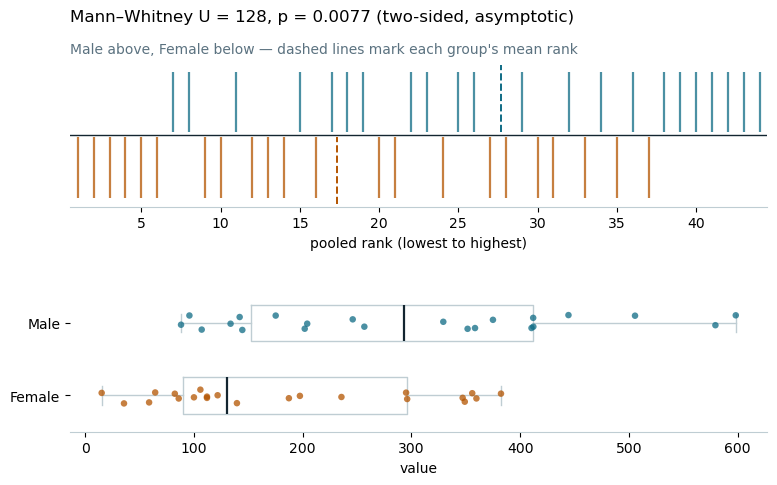

In [6]:
def plot_comparison(R, a, b, names, save_as=None, dpi=300):
    n1, n2, N = R["n1"], R["n2"], R["N"]
    ranks = R["ranks"]

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(9, 4.8), gridspec_kw={"height_ratios": [1, 1], "hspace": 0.55}
    )

    # --- rank ladder ---
    big = N > 1200
    if big:
        bins = np.linspace(0.5, N + 0.5, 121)
        ha, _ = np.histogram(ranks[:n1], bins=bins)
        hb, _ = np.histogram(ranks[n1:], bins=bins)
        scale = max(ha.max(), hb.max(), 1)
        centres = (bins[:-1] + bins[1:]) / 2
        width = bins[1] - bins[0]
        ax1.bar(centres, ha / scale, width=width, bottom=0.04, color=COL_A, alpha=0.8)
        ax1.bar(centres, -hb / scale, width=width, bottom=-0.04, color=COL_B, alpha=0.8)
    else:
        ax1.vlines(ranks[:n1], 0.04, 1.0, color=COL_A, lw=1.6, alpha=0.75)
        ax1.vlines(ranks[n1:], -0.04, -1.0, color=COL_B, lw=1.6, alpha=0.75)

    ax1.axvline(R["mean_rank_1"], 0.52, 0.98, color=COL_A, lw=1.4, ls="--")
    ax1.axvline(R["mean_rank_2"], 0.02, 0.48, color=COL_B, lw=1.4, ls="--")
    ax1.axhline(0, color="#132530", lw=1)
    ax1.set_xlim(0.5, N + 0.5)
    ax1.set_ylim(-1.15, 1.15)
    ax1.set_yticks([])
    ax1.set_xlabel("pooled rank (lowest to highest)")
    ax1.set_title(
        f"{names[0]} above, {names[1]} below — dashed lines mark each group's mean rank",
        fontsize=10, loc="left", color="#5B7280",
    )
    for side in ("left", "right", "top"):
        ax1.spines[side].set_visible(False)
    ax1.spines["bottom"].set_color("#BFCDD3")

    # --- raw values ---
    rng = np.random.default_rng(0)
    for i, (vals, col) in enumerate([(a, COL_A), (b, COL_B)]):
        y = i + rng.uniform(-0.11, 0.11, vals.size)
        ax2.scatter(vals, y, s=22, color=col, alpha=0.75, zorder=3, edgecolor="none")
    bp = ax2.boxplot(
        [a, b], vert=False, widths=0.5, positions=[0, 1], showfliers=False,
        medianprops=dict(color="#132530", lw=1.6),
        boxprops=dict(color="#BFCDD3"), whiskerprops=dict(color="#BFCDD3"),
        capprops=dict(color="#BFCDD3"),
    )
    ax2.set_yticks([0, 1])
    ax2.set_yticklabels(names)
    ax2.set_xlabel("value")
    ax2.invert_yaxis()
    for side in ("left", "right", "top"):
        ax2.spines[side].set_visible(False)
    ax2.spines["bottom"].set_color("#BFCDD3")

    p_txt = "p < 0.0001" if R["p"] < 1e-4 else f"p = {R['p']:.4f}"
    fig.suptitle(
        f"Mann–Whitney U = {R['U']:.4g}, {p_txt} ({R['alternative']}, {R['method']})",
        fontsize=12, x=0.125, ha="left", y=0.99,
    )
    if save_as:
        fig.savefig(save_as, dpi=dpi, bbox_inches="tight")
        print(f"saved {save_as}")
    plt.show()
    return fig


_ = plot_comparison(R, a, b, names)
# To save a publication-ready copy:
# _ = plot_comparison(R, a, b, names, save_as="mann_whitney.pdf")

## 5. Methods text

Copy-paste into your manuscript. Versions are read from the running environment, so they
describe the software that actually produced the numbers above. Check the sentences
against your journal's style guide before submitting, and delete anything you didn't use
(the one-sided wording, the Hodges–Lehmann CI, and so on).

In [7]:
def methods_text(R, names, versions=VERSIONS):
    alt = R["alternative"]
    if alt == "two-sided":
        alt_sentence = "Tests were two-sided"
    else:
        direction = ">" if alt == "greater" else "<"
        alt_sentence = (f"Tests were one-sided (alternative hypothesis: "
                        f"{names[0]} {direction} {names[1]})")

    if R["method"] == "exact":
        applied = "For the comparison reported here, the exact distribution was used."
    else:
        tie_note = (f" ({R['tied_values']} observations in {R['tie_sets']} tied "
                    f"set{'s' if R['tie_sets'] != 1 else ''})") if R["tie_sets"] else ""
        applied = ("For the comparison reported here, the asymptotic method was used"
                   + tie_note + ".")

    p_txt = "p < 0.0001" if R["p"] < 1e-4 else f"p = {R['p']:.4f}"
    ci_txt = ""
    if np.isfinite(R["hl_ci"][0]):
        ci_txt = (f" (Hodges-Lehmann shift = {R['hl']:.4g}, "
                  f"{int((1 - R['alpha']) * 100)}% CI "
                  f"{R['hl_ci'][0]:.4g} to {R['hl_ci'][1]:.4g})")

    methods = (
        f"Group comparisons were performed using the Mann-Whitney U test (Mann & Whitney, "
        f"1947), a rank-based nonparametric test of the null hypothesis that a randomly "
        f"selected value from one group is equally likely to be greater or smaller than a "
        f"randomly selected value from the other. {alt_sentence}, with statistical "
        f"significance set at alpha = {R['alpha']}. Tied observations were assigned the "
        f"mean of the ranks they span. Exact p-values were obtained by complete enumeration "
        f"of the null distribution of U when neither group exceeded {EXACT_MAX_N} "
        f"observations and no ties were present; otherwise p-values were obtained from the "
        f"normal approximation with a correction for ties and a continuity correction of "
        f"0.5. {applied} Effect sizes are reported as the rank-biserial correlation (Kerby, "
        f"2014) and as the common-language effect size, i.e. the probability that a randomly "
        f"drawn value from the first group exceeds a randomly drawn value from the second, "
        f"with ties contributing 0.5 (McGraw & Wong, 1992). Location shift was estimated by "
        f"the Hodges-Lehmann estimator, the median of all pairwise between-group "
        f"differences, with a distribution-free confidence interval derived from the "
        f"normal approximation to the rank-sum distribution (Hodges & Lehmann, 1963). "
        f"Medians and quartiles were computed by linear interpolation of the empirical "
        f"distribution function."
    )

    software = (
        f"All analyses were conducted in Python {versions['Python']} using SciPy "
        f"{versions['SciPy']} (Virtanen et al., 2020) and NumPy {versions['NumPy']} "
        f"(Harris et al., 2020); the Mann-Whitney U test was computed with "
        f"scipy.stats.mannwhitneyu. Data handling used pandas {versions['pandas']} "
        f"(McKinney, 2010) and figures were produced with Matplotlib "
        f"{versions['Matplotlib']} (Hunter, 2007). Analyses were run on "
        f"{versions['OS']} on {_dt.date.today().isoformat()}."
    )

    result = (
        f"{names[0]} (n = {R['n1']}, Mdn = {R['median_1']:.4g}, IQR {R['q1_1']:.4g}-"
        f"{R['q3_1']:.4g}) "
        + ("differed significantly from " if R["p"] < R["alpha"]
           else "did not differ significantly from ")
        + f"{names[1]} (n = {R['n2']}, Mdn = {R['median_2']:.4g}, IQR {R['q1_2']:.4g}-"
        f"{R['q3_2']:.4g}), Mann-Whitney U = {R['U']:.6g}"
        + (f", z = {R['z']:.3f}" if R["method"] == "asymptotic" else "")
        + f", {p_txt} ({alt}, {R['method']}), rank-biserial r = {R['rank_biserial']:.3f}, "
        f"common-language effect size = {R['cles']:.3f}{ci_txt}."
    )

    references = [
        "Harris, C. R., et al. (2020). Array programming with NumPy. Nature, 585, 357-362.",
        "Hodges, J. L., & Lehmann, E. L. (1963). Estimates of location based on rank tests. "
        "Annals of Mathematical Statistics, 34(2), 598-611.",
        "Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. Computing in Science & "
        "Engineering, 9(3), 90-95.",
        "Kerby, D. S. (2014). The simple difference formula: An approach to teaching "
        "nonparametric correlation. Comprehensive Psychology, 3, 11.IT.3.1.",
        "Mann, H. B., & Whitney, D. R. (1947). On a test of whether one of two random "
        "variables is stochastically larger than the other. Annals of Mathematical "
        "Statistics, 18(1), 50-60.",
        "McGraw, K. O., & Wong, S. P. (1992). A common language effect size statistic. "
        "Psychological Bulletin, 111(2), 361-365.",
        "McKinney, W. (2010). Data structures for statistical computing in Python. "
        "Proceedings of the 9th Python in Science Conference, 56-61.",
        "Virtanen, P., et al. (2020). SciPy 1.0: Fundamental algorithms for scientific "
        "computing in Python. Nature Methods, 17, 261-272.",
    ]

    return "\n\n".join([
        "METHODS", methods, software,
        "RESULTS SENTENCE", result,
        "REFERENCES", "\n".join(references),
    ])


text = methods_text(R, names)
print(text)

# Write it to a file alongside the notebook:
# open("methods.txt", "w").write(text)

METHODS

Group comparisons were performed using the Mann-Whitney U test (Mann & Whitney, 1947), a rank-based nonparametric test of the null hypothesis that a randomly selected value from one group is equally likely to be greater or smaller than a randomly selected value from the other. Tests were two-sided, with statistical significance set at alpha = 0.05. Tied observations were assigned the mean of the ranks they span. Exact p-values were obtained by complete enumeration of the null distribution of U when neither group exceeded 20 observations and no ties were present; otherwise p-values were obtained from the normal approximation with a correction for ties and a continuity correction of 0.5. For the comparison reported here, the asymptotic method was used. Effect sizes are reported as the rank-biserial correlation (Kerby, 2014) and as the common-language effect size, i.e. the probability that a randomly drawn value from the first group exceeds a randomly drawn value from the second,

## 6. Optional: many comparisons at once

Useful when you're testing the same two groups across a set of variables — principal
components, for instance. Give it a long-format dataframe with one grouping column and a
list of value columns; it returns per-variable statistics with Benjamini–Hochberg adjusted
p-values, since a screen across many variables needs multiplicity control.

In [8]:
def benjamini_hochberg(p):
    """Return BH-adjusted p-values (FDR) for a 1-D array of p-values."""
    p = np.asarray(p, float)
    m = p.size
    order = np.argsort(p)
    ranked = p[order] * m / np.arange(1, m + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    out = np.empty(m)
    out[order] = np.clip(ranked, 0, 1)
    return out


def compare_many(df, group_col, value_cols, alternative="two-sided", alpha=0.05):
    """Mann-Whitney U for each value column, split by a two-level grouping column."""
    levels = pd.unique(df[group_col].dropna())
    if len(levels) != 2:
        raise ValueError(f"{group_col!r} must have exactly 2 levels, found {len(levels)}.")
    g1, g2 = levels

    rows = []
    for col in value_cols:
        x = df.loc[df[group_col] == g1, col].dropna().to_numpy(float)
        y = df.loc[df[group_col] == g2, col].dropna().to_numpy(float)
        r = run_mann_whitney(x, y, alternative=alternative, alpha=alpha)
        rows.append({
            "variable": col, f"n_{g1}": r["n1"], f"n_{g2}": r["n2"],
            f"median_{g1}": r["median_1"], f"median_{g2}": r["median_2"],
            "U": r["U"], "z": r["z"], "p": r["p"],
            "rank_biserial": r["rank_biserial"], "cles": r["cles"],
            "shift": r["hl"], "method": r["method"],
        })

    out = pd.DataFrame(rows)
    out["p_BH"] = benjamini_hochberg(out["p"].to_numpy())
    return out.sort_values("p").reset_index(drop=True)


# Demo on synthetic PC scores: only PC4 actually separates the two clusters.
rng = np.random.default_rng(7)
demo = pd.DataFrame({
    "cluster": ["A"] * 30 + ["B"] * 30,
    "PC1": rng.normal(0, 3, 60),
    "PC2": rng.normal(0, 2, 60),
    "PC3": rng.normal(0, 1.5, 60),
    "PC4": np.r_[rng.normal(0.6, 1, 30), rng.normal(-0.6, 1, 30)],
})
compare_many(demo, "cluster", ["PC1", "PC2", "PC3", "PC4"]).round(4)

,variable,n_A,n_B,median_A,median_B,U,z,p,rank_biserial,cles,shift,method,p_BH
0,PC4,30,30,1.1179,-0.7281,87.0,5.3594,0.0000,0.8067,0.9033,1.8277,asymptotic,0.0000
1,PC1,30,30,-0.7638,0.0469,351.0,-1.4563,0.1453,-0.2200,0.3900,-1.0969,asymptotic,0.2906
2,PC3,30,30,-0.2045,-0.5265,417.0,0.4805,0.6309,0.0733,0.5367,0.1572,asymptotic,0.8412
3,PC2,30,30,-0.3935,-0.0295,445.0,-0.0665,0.9470,-0.0111,0.4944,-0.0379,asymptotic,0.9470


## What this test does and doesn't tell you

- It compares **whole distributions**, not medians. A significant result means one group
  tends to produce higher values. Read it as a difference in medians only when the two
  distributions have a similar shape and spread.
- **Independence still matters.** Being distribution-free doesn't rescue repeated measures
  or clustered sampling — use the Wilcoxon signed-rank test for paired data.
- **Small samples have little power.** With fewer than about five values per group, a
  large p-value mostly reflects sample size.
- **Heavy ties weaken it.** Many tied values shrink the variance of U and the asymptotic
  approximation becomes the only option available.
- If you're screening many variables, report the BH-adjusted p-values from step 6 rather
  than the raw ones.